In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks", context =  "talk", palette = "husl")

In [4]:
import cv2

In [5]:
import tensorflow as tf

In [6]:
from tensorflow.keras import layers, models, optimizers, applications, Input

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [9]:
from tqdm import tqdm

In [10]:
import random

In [11]:
import os

In [ ]:
import shap

In [13]:
shap.__version__

'0.47.2'

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.utils.class_weight import compute_class_weight

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
from sklearn.svm import SVC

In [20]:
from sklearn.svm import LinearSVC

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

In [23]:
from sklearn.metrics import f1_score

In [24]:
from sklearn.metrics import classification_report

In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
import time

In [27]:
# ====================================
# FIXER les SEEDS globales
# ====================================
SEED = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [28]:
X_tr = pd.read_csv("../../../002_Dataset_ALL/X_train_update.csv", index_col=0)
y_tr = pd.read_csv("../../../002_Dataset_ALL/Y_train_CVw08PX.csv", index_col=0)
# X_ts = pd.read_csv("../../../002_Dataset_ALL/X_test_update.csv", index_col=0)

In [29]:
X_tr

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [30]:
# Analyse de la variable cibe y_tr
y_tr

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
...,...
84911,40
84912,2583
84913,2280
84914,1560


In [31]:
# vérifier les catégories de y_train
print("le nombre total des classes de prdtypecode: \n", y_tr['prdtypecode'].nunique())
print("les classes de prdtypecode : \n", y_tr.value_counts())

le nombre total des classes de prdtypecode: 
 27
les classes de prdtypecode : 
 prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64


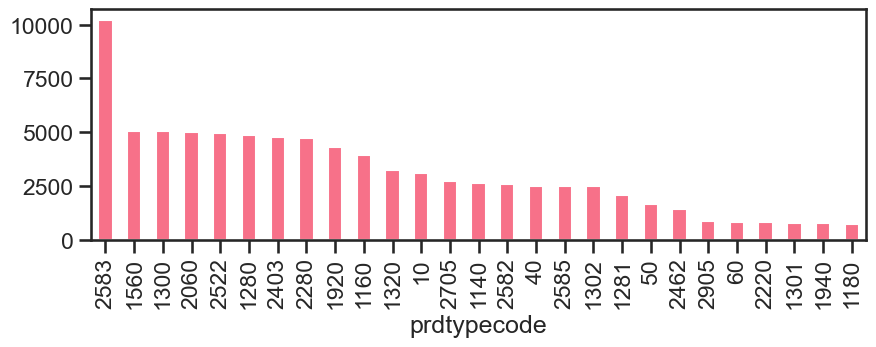

In [32]:
# Vérifier la distribution des prdtypecode :
y_tr['prdtypecode'].value_counts().plot(kind='bar', figsize=(10,3));

In [33]:
# fusion de X_tr et y_tr
fusion = y_tr.merge(X_tr, left_index=True, right_index=True)
display(X_tr.head(2))
display(X_tr.tail(2))
display(y_tr.head(2))
display(y_tr.tail(2))
display(fusion)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237


,designation,description,productid,imageid
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403
84915,Gomme De Collection 2 Gommes Pinguin Glace Ver...,NaN,57203227,684671297


,prdtypecode
0,10
1,2280


,prdtypecode
84914,1560
84915,2522


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,1280,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,2705,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...,...
84911,40,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,2583,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,2280,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,1560,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [34]:
# afficher les lignes concernant le prdtypecode le plus fréquent (2583)
fusion.loc[fusion['prdtypecode'] == 2583]
# remarque: ces produits sont liés à la 'piscine'

,prdtypecode,designation,description,productid,imageid
20,2583,Kit de désinfection pour piscines enfants 20990,NaN,3936362802,1268740880
39,2583,Bouée gonflable River tube - OOGARDEN,Bouée gonflable River tube en PVC idéale pour ...,3147314797,1225887302
53,2583,Testeur électronique de pH,Utilisation du Testeur électronique de pHGrâce...,207151480,941622055
58,2583,Pompe de filtration Speck Badu 95,NaN,4128438373,1295960377
64,2583,AstralCom 1 CV Mono de DAB - Surpresseur piscine,Tension (V) : Monophasé - 230 V Puissance : 1...,1857269337,1105831362
...,...,...,...,...,...
84874,2583,Skimmer standard petite meurtrière - Vis PARKE...,Type de pièces : Skimmer Revêtement : Liner ...,2151623756,1128623127
84887,2583,Linxor - Bâche à Bulles 300 microns piscine 2m...,NaN,1951685693,1317940307
84905,2583,Bâche été pour piscine Lili Ø 255 m,<p>La <strong>bâche été</strong> permet d&#39;...,1886035156,1109239046
84909,2583,espa - kit complet de nage à contre courant 39...,espa espa - kit complet de nage à contre coura...,853455937,1043841028


In [35]:
fusion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB


In [36]:
essai6 = fusion.copy()
print(essai6.info())
display(essai6.head(3))

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB
None


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978


In [37]:
# ================================================================
# 3. FONCTION DE PRÉTRAITEMENT D'UNE IMAGE
# ================================================================

def color_crop_square_resize(filepath, final_size=(128, 128)):
    """
    Lecture image couleur,
    crop des bordures blanches,
    mise au carré (padding blanc),
    redimensionnement final.
    """
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    
    if img is None:
        return np.full((final_size[1], final_size[0], 3), 255, dtype=np.uint8)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    coords = cv2.findNonZero(thresh)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    h, w = img.shape[:2]
    if h != w:
        size = max(h, w)
        square = np.full((size, size, 3), 255, dtype=np.uint8)
        y0 = (size - h) // 2
        x0 = (size - w) // 2
        square[y0:y0+h, x0:x0+w] = img
        img = square

    img = cv2.resize(img, final_size, interpolation=cv2.INTER_AREA)

    return img

In [38]:
# ================================================================
# 4. AJOUTE LA COLONNE DES PATHS D’IMAGES DANS essai6
# ================================================================
essai6["imagepath"] = essai6.apply(
    lambda r: f"image_{r.imageid}_product_{r.productid}.jpg",
    axis=1)
display(essai6.head(2))

,prdtypecode,designation,description,productid,imageid,imagepath
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,image_1263597046_product_3804725264.jpg
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,image_1008141237_product_436067568.jpg


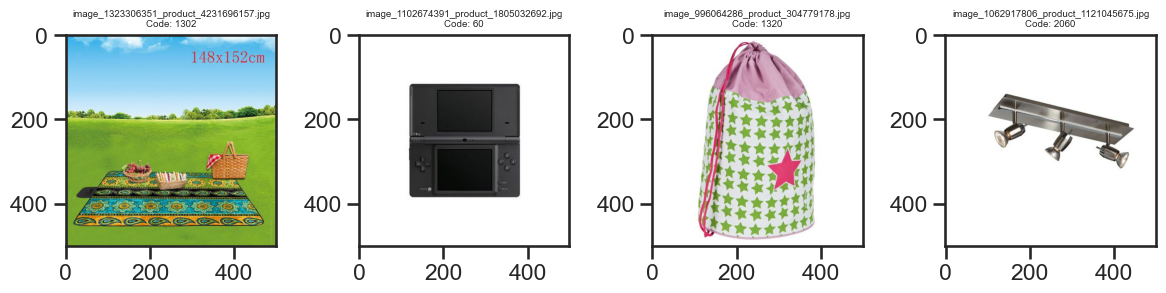

In [39]:
# ================================================================
# 4.2. FONCTION POUR VISUALISER QUELQUES IMAGES d'origine
# ================================================================

def visualize_images_from_df(df, image_folder, n=5):

    sample = df.sample(n)

    plt.figure(figsize=(3*n, 4))

    for i, (_, row) in enumerate(sample.iterrows()):
        image_name = row["imagepath"]
        code = row["prdtypecode"]

        image_path = os.path.join(image_folder, image_name)

        img = plt.imread(image_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)

        # Titre = nom du fichier + code
        plt.title(f"{image_name}\nCode: {code}", fontsize=7)

        # plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_images_from_df(essai6, "../data/raw_images", n=4)

In [40]:
# ================================================================
# 5. FONCTION POUR VISUALISER QUELQUES IMAGES PREPROCESSÉES
# ================================================================

def visualize_preprocessed(df, image_folder, n=5):
    sample = df.sample(n)

    plt.figure(figsize=(3*n, 4))

    for i, (_, row) in enumerate(sample.iterrows()):
        image_name = row["imagepath"]
        code = row["prdtypecode"]

        filepath = os.path.join(image_folder, image_name)
        img = color_crop_square_resize(filepath, final_size=(128, 128))

        plt.subplot(1, n, i+1)
        plt.imshow(img)

        # Titre = nom du fichier + code
        plt.title(f"{image_name}\nCode: {code}", fontsize=7)
        # plt.axis("off")

    plt.tight_layout()
    plt.show()


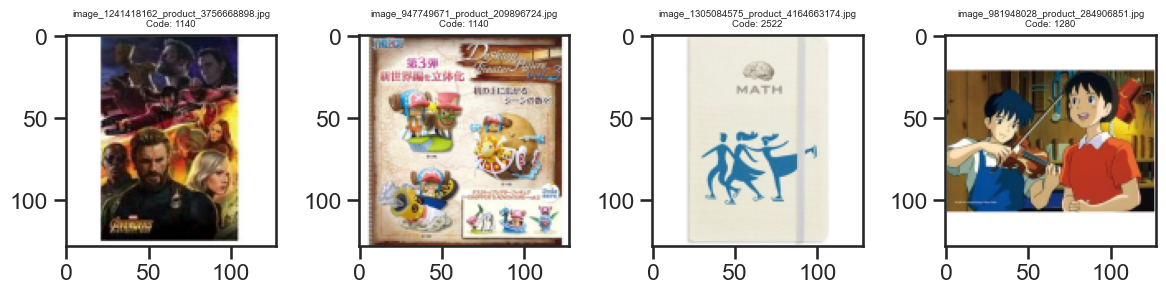

In [41]:
# ================================================================
# 6. TEST en utilisant la FONCTION POUR VISUALISER QUELQUES IMAGES PREPROCESSÉES
# ================================================================
image_folder="../data/raw_images"
visualize_preprocessed(essai6, image_folder, n=4)

In [52]:
# ================================================================
# /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ /!\ 
# ================================================================
# FAIRE UNE SEUL FOIS (A NE PAS REFAIRE) la partie
# "6. TRATTER TOUTES LES ~ 85k images et ENREGISTRER dans le dossiers"
# ci-dessous
# ================================================================

# ================================================================
# 6. TRATTER TOUTES LES ~ 85k images et ENREGISTRER dans le dossiers
# ================================================================

# ---------------------------------------------------
# 1. Définir les dossiers
# ---------------------------------------------------
raw_folder = "../data/raw_images"        # dossier source
processed_folder = "../data/processed_128"  # dossier de sortie

# Créer le dossier processed_128 s'il n'existe pas
os.makedirs(processed_folder, exist_ok=True)

# ---------------------------------------------------
# 2. Lister toutes les images du dossier raw_images
# ---------------------------------------------------
image_files = [f for f in os.listdir(raw_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"Nombre d'images à traiter : {len(image_files)}")

# ---------------------------------------------------
# 3. Prétraiter et enregistrer chaque image
# ---------------------------------------------------
for image_name in tqdm(image_files, desc="Prétraitement des images"):
    raw_path = os.path.join(raw_folder, image_name)
    processed_path = os.path.join(processed_folder, image_name)

    # Prétraitement avec la fonction existante
    img = color_crop_square_resize(raw_path, final_size=(128, 128))

    # Convertir RGB → BGR pour OpenCV afin d'enregistrer correctement
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Sauvegarder l'image prétraitée
    cv2.imwrite(processed_path, img_bgr)

print("Toutes les images ont été prétraitées et enregistrées dans 'processed_128'.")


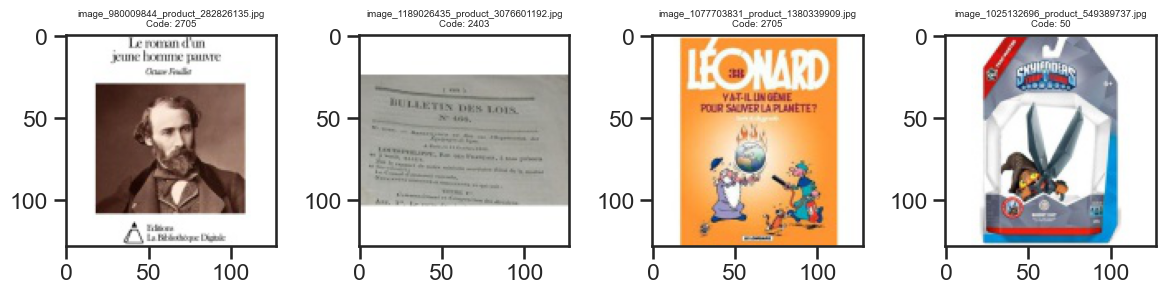

In [42]:
# ================================================================
# 7. VERIFIER / VISUALISER quelques images prétraité (le dossier processed_128)
# ================================================================

visualize_images_from_df(essai6, "../data/processed_128", n=4)

In [54]:
# # ================================================================
# # 8. CRÉER UN MINIDATASET POUR TESTER RAPIDEMENT
# # Uniquement au début, pour vérifier si ça fonctionne
# # Si tout fonctionne avec le minidataset, on peut travailler directement avec le Dataset complet de de ~85k IMAGES
# # ================================================================
# mini_df = essai6.sample(20000, random_state=42)

# train_df, test_df = train_test_split(
#     mini_df,
#     test_size=0.2,
#     stratify=mini_df["prdtypecode"],
#     random_state=SEED
# )

# train_df, val_df = train_test_split(
#     train_df,
#     test_size=0.2,
#     stratify=train_df["prdtypecode"],
#     random_state=SEED
# )

In [43]:
# ================================================================
# 8. REEL TRAIN, VAL, TEST POUR TOUT LE DATASET de ~85k IMAGES
# ================================================================
train_df, test_df = train_test_split(
    essai6,
    test_size=0.2,
    stratify=essai6["prdtypecode"],
    random_state=SEED  # fixer random state
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["prdtypecode"],
    random_state=SEED  # fixer random state
)

In [44]:
# ================================================================
# 8. CRÉER UN MINIDATASET POUR TESTER RAPIDEMENT
# 8.2 Vérifier le nombre total de labels (nombre de classes uniques) dans le MINIDATASET (mini_df)
# ================================================================

print("Train :", train_df["prdtypecode"].nunique(), "classes")
print("Val   :", val_df["prdtypecode"].nunique(), "classes")
print("Test  :", test_df["prdtypecode"].nunique(), "classes")

Train : 27 classes
Val   : 27 classes
Test  : 27 classes


In [45]:
# ================================================================
# 8. CRÉER UN MINIDATASET POUR TESTER RAPIDEMENT
# 8.2 Vérifier combien d'images par classe dans chaque set dans le MINIDATASET (mini_df)
# ================================================================
summary = pd.DataFrame({
    "train_count": train_df["prdtypecode"].value_counts(),
    "val_count":   val_df["prdtypecode"].value_counts(),
    "test_count":  test_df["prdtypecode"].value_counts()
}).fillna(0).astype(int)

display(summary)

,train_count,val_count,test_count
prdtypecode,,,
2583,6533,1634,2042
1560,3246,812,1015
1300,3229,807,1009
2060,3195,799,999
2522,3193,798,998
1280,3117,779,974
2403,3055,764,955
2280,3046,762,952
1920,2753,689,861


In [46]:
# ================================================================
# 9. PREPA pour 1 Modèle CNN 
# ================================================================
# 9.1. PARAMETRES
# ================================================================
IMG_SIZE = 128  # Taille de l’image (128×128 pixels)
BATCH_SIZE = 32  # On va entraîner le modèle avec des lots de 32 images à la fois
NUM_CLASSES = essai6["prdtypecode"].nunique()  #nb total de classes uniques (codes produits) =la taille de la couche softmax finale du CNN.

# mapping labels → indices
# car TensorFlow n’aime pas les labels comme 10, 60 ou 1140. C'est mieux des labels 0, 1, 2, …, N-1.

# crée un dictionnaire pour convertir le code produit vers un index, ex: 10 =>0, 60 =>1, 1140 => 2, ...
label_to_idx = {c: i for i, c in enumerate(sorted(essai6["prdtypecode"].unique()))}

# Inverse du dictionnaire (utile pour prédire ensuite).
idx_to_label = {v: k for k, v in label_to_idx.items()}

# Chemin du dossier contenant les images déjà redimensionnées.
image_folder = "../data/processed_128" 

# ================================================================
# 9.2. Fonction pour créer tf.data.Dataset
# ================================================================
# Explication Pourquoi créer train_ds, val_ds, test_ds avec tf.data.Dataset
# TensorFlow ne peut pas entraîner un modèle directement à partir d’un DataFrame Pandas.
# Un modèle CNN a besoin de données sous un format efficace, capable de :

# charger les images au fur et à mesure (pas charger 84 916 images en RAM !)

# paralléliser les opérations (chargement, décodage)

# pré-traiter les images de manière rapide

# “batcher” les images pour accélérer l’entraînement sur GPU

# shuffle les données pour éviter d’apprendre l’ordre du dataframe

# précharger les prochains batchs pour utiliser 100 % du GPU
# ================================================================

# Fonction pour transformer un DataFrame Pandas en Dataset TensorFlow
def df_to_dataset(df, shuffle=True):
    paths = [os.path.join(image_folder, p) for p in df["imagepath"]]  # Pour chaque nom dans df["imagepath"], on crée un chemin complet vers l’image.
    labels = df["prdtypecode"].map(label_to_idx).tolist() # convertit les labels originaux en indices numériques (0,1,2,...)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)) # crée un Dataset qui contient un chemin d’image ET un label associé

    # Fonction pour charger l'image
    def load_image(path, label):
        img = tf.io.read_file(path)  # Ouvre le fichier image (chargement brut en bytes).
        img = tf.image.decode_jpeg(img, channels=3)  # Décode l’image JPEG et force 3 canaux (couleur)
        img = tf.image.convert_image_dtype(img, tf.float32)  # Convertit les pixels en flottants entre 0 et 1 (normalisation).
        label = tf.one_hot(label, NUM_CLASSES)  #Convertit le label en vecteur one-hot (ex : classe 2 sur 5 → [0,0,1,0,0])
        return img, label  # retourne (image prétraitée, label one-hot)
    
    # Applique load_image en parallèle sur plusieurs CPU pour aller plus vite. AUTOTUNE = TensorFlow optimise automatiquement.
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)  

    # Mélange optionnel
    if shuffle:
        ds = ds.shuffle(200, seed=SEED)  # Mélange aléatoire avec un buffer de 200 images. Seulement pour train, pas val/test.SEED défini plus haut

    # Batch + Préchargement
    # batch(BATCH_SIZE) : regroupe les images par lot (ex: 32 images)
    # prefetch() : pendant que le GPU entraîne le modèle,TensorFlow charge déjà le batch suivant => gain en performance   
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# ================================================================
# 9.3. Créer les datasets
# ================================================================
train_ds = df_to_dataset(train_df)  # Mélange aléatoire avec un buffer de 200 images. Seulement pour train
val_ds   = df_to_dataset(val_df, shuffle=False)  # Pas de Mélange aléatoire
test_ds  = df_to_dataset(test_df, shuffle=False)  # Pas de Mélange aléatoire

In [47]:
# ================================================================
# 9. PREPA pour 1 Modèle CNN 
# ================================================================
# 9.4. Vérifier que les images sont normalisé entre 0 et 1
# Normalemement, la normalisation est faite avec cett ligne dans le § 9.2 ci-dessus
# img = tf.image.convert_image_dtype(img, tf.float32)  # Convertit les pixels en flottants entre 0 et 1 (normalisation).
# ================================================================

for imgs, labels in train_ds.take(1):
    print("min pixel:", imgs.numpy().min())
    print("max pixel:", imgs.numpy().max())

min pixel: 0.0
max pixel: 1.0


In [48]:
# ================================================================
# 10. Callbacks
# ================================================================
# Callback pour Arrêter plus tôt
early_stopping = EarlyStopping(
                                patience=4, # Attendre 4 epochs avant application
                                min_delta=0.01, # si au bout de 4 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss',
                                restore_best_weights=True)

# Callback pour réduire le taux d'apprentissage
reduce_LR = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.5,  # On réduit le learning rate d'un facteur 0.5
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)
# Callback pour sauvegarder le modèle
model_checkpoint = ModelCheckpoint(
    'best_val_loss_57.h5',  
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    save_weights_only=True  
)

In [49]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.3. Cosntruction Model
# ================================================================
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(64, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 63, 63, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                         

In [62]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.2 Entraînement 
# ================================================================
start=time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,   # 10 suffit
    callbacks = [early_stopping,model_checkpoint, reduce_LR] 
)

end=time.time()
print("Duree (min) = ", (end-start)/60)

Epoch 1/10
1699/1699 [==============================] - 1029s 605ms/step - loss: 2.6788 - accuracy: 0.2365 - val_loss: 2.3733 - val_accuracy: 0.3277 - lr: 0.0010
Epoch 2/10
1699/1699 [==============================] - 959s 565ms/step - loss: 2.3374 - accuracy: 0.3261 - val_loss: 2.1982 - val_accuracy: 0.3708 - lr: 0.0010
Epoch 3/10
1699/1699 [==============================] - 954s 561ms/step - loss: 2.1994 - accuracy: 0.3635 - val_loss: 2.0989 - val_accuracy: 0.3888 - lr: 0.0010
Epoch 4/10
1699/1699 [==============================] - 968s 570ms/step - loss: 2.1020 - accuracy: 0.3886 - val_loss: 2.0341 - val_accuracy: 0.4056 - lr: 0.0010
Epoch 5/10
1699/1699 [==============================] - 952s 560ms/step - loss: 1.9615 - accuracy: 0.4207 - val_loss: 1.9898 - val_accuracy: 0.4196 - lr: 0.0010
Epoch 7/10
1699/1699 [==============================] - 1248s 734ms/step - loss: 1.8396 - accuracy: 0.4472 - val_loss: 1.9810 - val_accuracy: 0.4267 - lr: 0.0010
Epoch 9/10
1699/1699 [==========

In [66]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.3.2 ENREGISTRER le modele
# ================================================================
# OPTION A — Sauvegarde complète 
# ================================================================
model.save("model_57.keras")

# ================================================================
# Recharger le modèle (plus tard)
# ================================================================
# model = tf.keras.models.load_model("model_57.keras")


In [67]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.3.2 ENREGISTRER le modele
# ================================================================
# OPTION B — Sauvegarde HDF5 (.h5)
# ================================================================
model.save("model_57.h5")

# ================================================================
# Recharger le modèle
# ================================================================
# model = tf.keras.models.load_model("model_57.h5")


In [68]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.3.2 ENREGISTRER le modele
# ================================================================
# OPTION C — Sauvegarder uniquement les poids
# ================================================================
model.save_weights("model_weights_57.h5")

# ================================================================
# Recharger le modèle ((nécessite d’avoir reconstruit le même modèle)
# ================================================================
# model.load_weights("model_weights_57.h5")


In [ ]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.2.01 Sauvegarder history (valeur de accuracy et loss pendant l'entrainement), pour pouvoir réutiliser plus tard
# ================================================================
# Convertir chaque liste de valeurs en float Python
history_clean = {key: [float(x) for x in values] 
                 for key, values in history.history.items()}

with open("history_57.json", "w") as f:
    json.dump(history_clean, f)


# # ================================================================
# # 11.2.02. Récupérer (valeur de accuracy et loss pendant l'entrainement), pour pouvoir réutiliser plus tard
# # ================================================================


# with open("history_57.json", "r") as f:
#     history_loaded = json.load(f)

# acc = history_loaded["accuracy"]
# val_acc = history_loaded["val_accuracy"]
# loss = history_loaded["loss"]
# val_loss = history_loaded["val_loss"]

# epochs_range = range(len(acc))


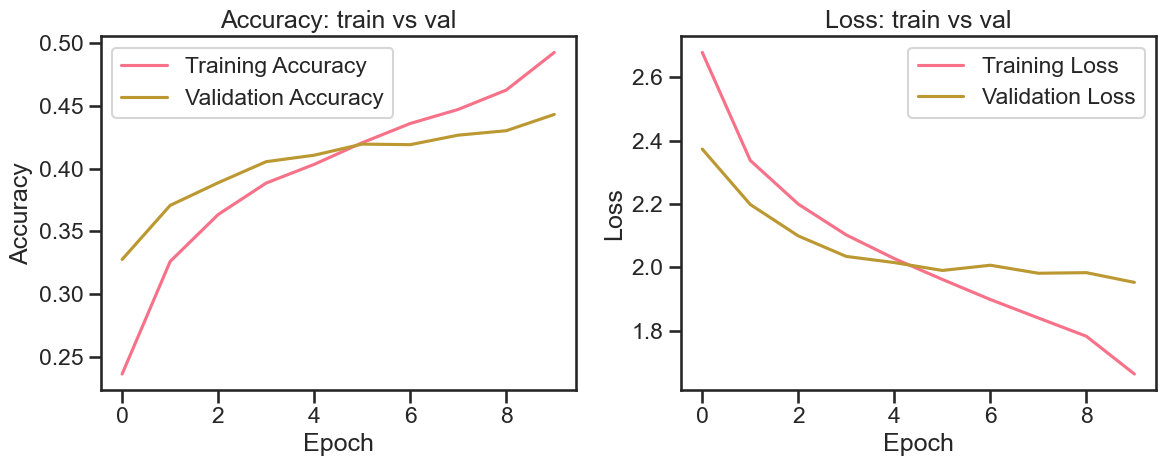

In [64]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 11.2.2 Courbe Loss et Accuracy de Train et Validation
# ================================================================

# Récupération des métriques
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# --- Plot des courbes ---
plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy: train vs val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss: train vs val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [65]:
# ================================================================
# 11. Créer un modèle CNN personalisé
# ================================================================
# 10.3. Evaluation sur le MINIDATASET
# ================================================================
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

531/531 [==============================] - 78s 147ms/step - loss: 1.9790 - accuracy: 0.4405
Test accuracy: 0.44053226709365845
Test loss: 1.978952407836914


In [69]:
# ================================================================
# 10. Modèle CNN avec l’API fonctionnelle
# ================================================================
# 10.4. Prédictions sur le test set
# ================================================================
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs)
    # labels one-hot → indices
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 [==============================] - 0s 289ms/step


In [70]:
# ================================================================
# 10. Modèle CNN avec l’API fonctionnelle
# ================================================================
# 10.5. F1-score par classe
# macro avg >> c'est macro F1 
# weighted avg >> moyenne pondérée par la taille de chaque classe =>> Weighted F1 
# ================================================================
target_names = [str(c) for c in sorted(essai6["prdtypecode"].unique())]

report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

          10     0.5026    0.3066    0.3809       623
          40     0.5441    0.4303    0.4805       502
          50     0.3559    0.1250    0.1850       336
          60     0.3514    0.0783    0.1281       166
        1140     0.4163    0.3165    0.3596       534
        1160     0.7906    0.8306    0.8101       791
        1180     0.4000    0.0131    0.0253       153
        1280     0.1860    0.2782    0.2230       974
        1281     0.1407    0.0459    0.0692       414
        1300     0.3546    0.5223    0.4224      1009
        1301     0.5714    0.0248    0.0476       161
        1302     0.2126    0.0542    0.0864       498
        1320     0.3047    0.1914    0.2351       648
        1560     0.3220    0.4926    0.3894      1015
        1920     0.7401    0.6318    0.6817       861
        1940     0.3258    0.1801    0.2320       161
        2060     0.2896    0.3423    0.3138       999
   

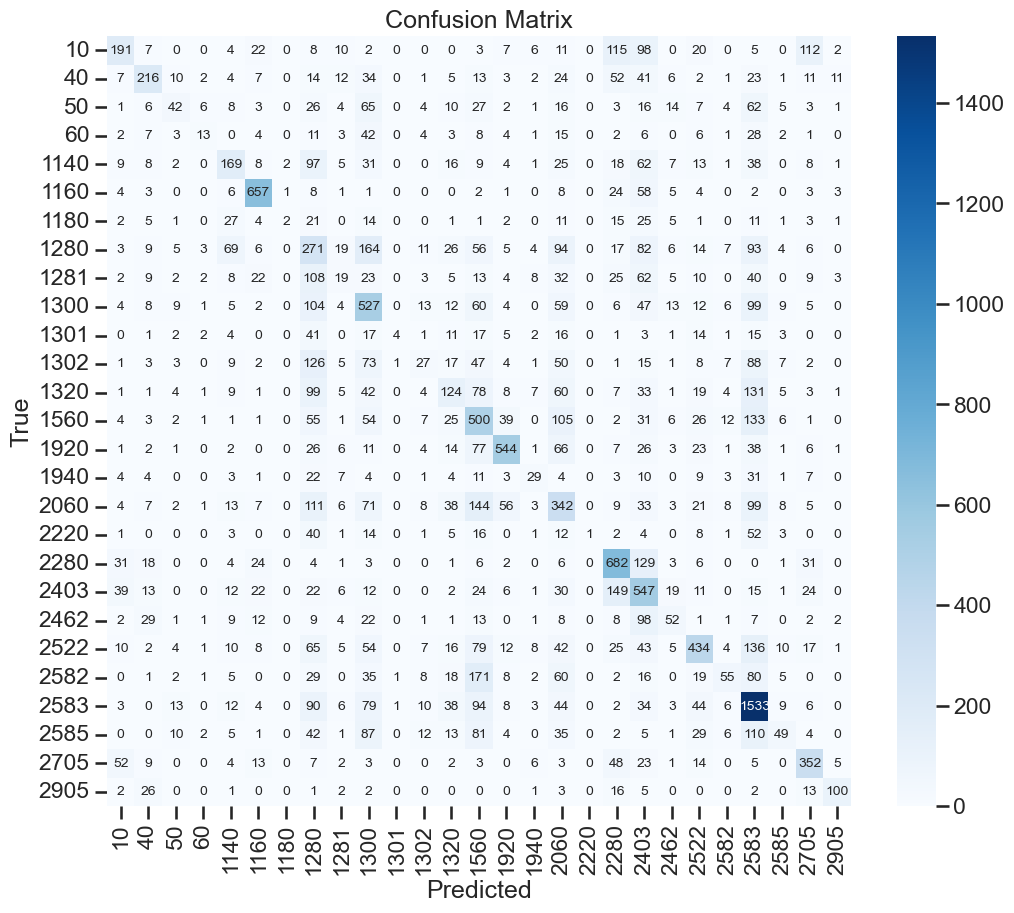

In [71]:
# ================================================================
# 10. Modèle CNN avec l’API fonctionnelle
# ================================================================
# 10.6. Heatmap de la Matrice de confusion
# ================================================================
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True,           # afficher les valeurs dans les cases
    fmt='d',              # format entier
    annot_kws={"size": 10},   # la taille du texte dans les cases
    cmap='Blues', 
    xticklabels=sorted(essai6["prdtypecode"].unique()), 
    yticklabels=sorted(essai6["prdtypecode"].unique())
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


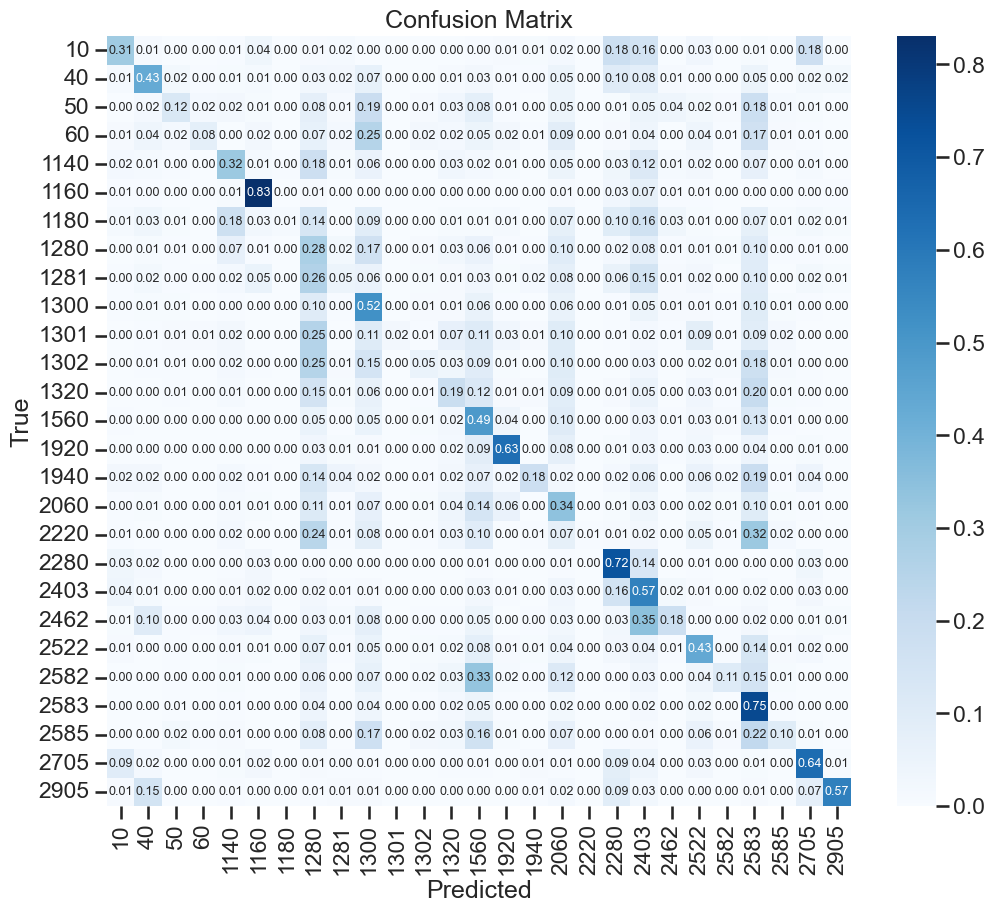

In [72]:
# ================================================================
# 10. Modèle CNN avec l’API fonctionnelle
# ================================================================
# 10.6. Heatmap de la Matrice de confusion (en proportion)
# ================================================================
# Matrice de confusion ((en proportion)
cm = confusion_matrix(y_true, y_pred, normalize='true')

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True,           # afficher les valeurs dans les cases
    fmt='.2f',              # 2 chiffres arpès virgule
    annot_kws={"size": 9},   # la taille du texte dans les cases
    cmap='Blues', 
    xticklabels=sorted(essai6["prdtypecode"].unique()), 
    yticklabels=sorted(essai6["prdtypecode"].unique())
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

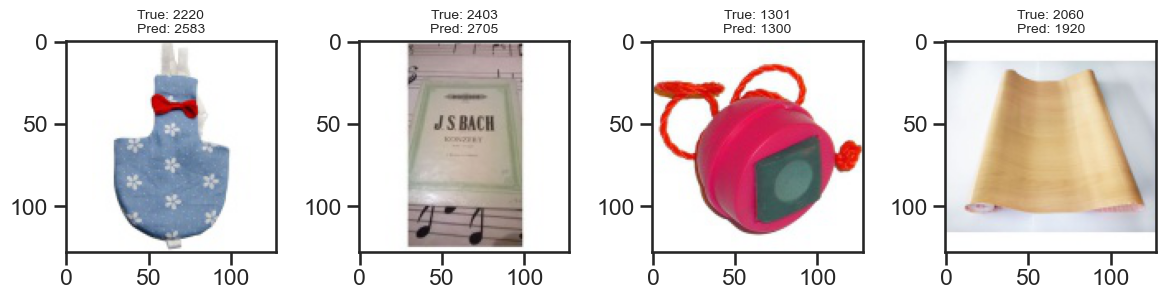

In [73]:
# ================================================================
# 10. Modèle CNN avec l’API fonctionnelle
# ================================================================
# 10.7. Afficher quelques mauvaises prédictions
# ================================================================

# On récupère les chemins des images dans le test set
test_paths = [os.path.join(image_folder, p) for p in test_df["imagepath"]]
test_labels = test_df["prdtypecode"].map(label_to_idx).tolist()

# Trouver les indices où la prédiction est incorrecte
wrong_indices = np.where(np.array(y_true) != np.array(y_pred))[0]

# Si moins de 4 erreurs, on ajuste
n_wrong = min(4, len(wrong_indices))

plt.figure(figsize=(12, 4))
for i in range(n_wrong):
    idx = wrong_indices[i]
    img_path = test_paths[idx]
    
    # Lire et afficher l'image
    img = plt.imread(img_path)
    
    plt.subplot(1, n_wrong, i+1)
    plt.imshow(img)
    true_label = idx_to_label[y_true[idx]]
    pred_label = idx_to_label[y_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    # plt.axis("off")

plt.tight_layout()
plt.show()


In [74]:
# ================================================================
# 11. INTERPRETABILITE : Grad-CAM
# ================================================================
# --------------------------------------------------------
# 1) Charger une image individuelle depuis son chemin
# → même préprocessing que df_to_dataset()
# --------------------------------------------------------
def load_single_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)   # [0,1]
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img


# --------------------------------------------------------
# 2) Fonction Grad-CAM adaptée au modèle CNN
# --------------------------------------------------------
def grad_cam(image, model, layer_name):
    """
    image : tensor (128,128,3) déjà normalisé entre [0,1]
    model : modèle CNN entraîné
    layer_name : nom d'une couche Conv2D
    """

    # Récupérer la couche convolutive
    conv_layer = model.get_layer(layer_name)

    # Modèle intermédiaire :
    #  - activations de la couche sélectionnée
    #  - prédiction finale
    grad_model = Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )

    # Ajout d’une dimension batch → shape (1,128,128,3)
    img_batch = tf.expand_dims(image, axis=0)

    # Calcul du gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    # Gradient du score par rapport aux activations
    grads = tape.gradient(loss, conv_outputs)

    # Moyenne des gradients par canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Activation de la couche convolutive (sans batch)
    conv_outputs = conv_outputs[0]

    # Pondération par les gradients
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalisation entre 0 et 1
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()

    # Redimensionnement à la taille d'entrée du CNN
    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy()
    heatmap = np.squeeze(heatmap)

    # Colorisation (palette jet)
    heatmap_color = plt.cm.jet(heatmap)[..., :3]

    # Superposition avec l’image d’origine
    superimposed = heatmap_color * 0.8 + image.numpy()*0.2
    superimposed = np.clip(superimposed, 0, 1)

    return superimposed, int(predicted_class.numpy())


# --------------------------------------------------------
# 3) Visualisation Grad-CAM sur plusieurs couches du CNN
# --------------------------------------------------------

def show_grad_cam_from_paths(image_paths, model):
    """
    image_paths : liste de chemins d’images
    model : modèle CNN
    """

    # Chargement des images (tensor)
    images = [load_single_image(p) for p in image_paths]
    images = tf.stack(images, axis=0)

    # Détection automatique des couches convolutionnelles
    conv_layers = [
        layer.name for layer in model.layers
        if isinstance(layer, Conv2D)
    ]

    n_images = len(images)

    # --- Ajout d'1 ligne pour afficher les images originales ---
    total_rows = 1 + len(conv_layers)

    plt.figure(figsize=(4 * n_images, 4 * total_rows))

    # ------------------------------------------------------------
    # 1) Ligne 1 — Images originales
    # ------------------------------------------------------------
    for i in range(n_images):
        plt.subplot(total_rows, n_images, i + 1)
        plt.imshow(images[i])
        plt.title("Image originale")
        plt.axis("off")

    # ------------------------------------------------------------
    # 2) Lignes suivantes — Grad-CAM pour chaque couche conv
    # ------------------------------------------------------------
    for row, layer in enumerate(conv_layers):

        for col in range(n_images):
            grad_img, pred_class = grad_cam(images[col], model, layer)

            plt.subplot(total_rows, n_images, (row + 1) * n_images + col + 1)
            plt.imshow(grad_img)
            plt.title(f"{layer}\nPrédiction : {idx_to_label[pred_class]}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


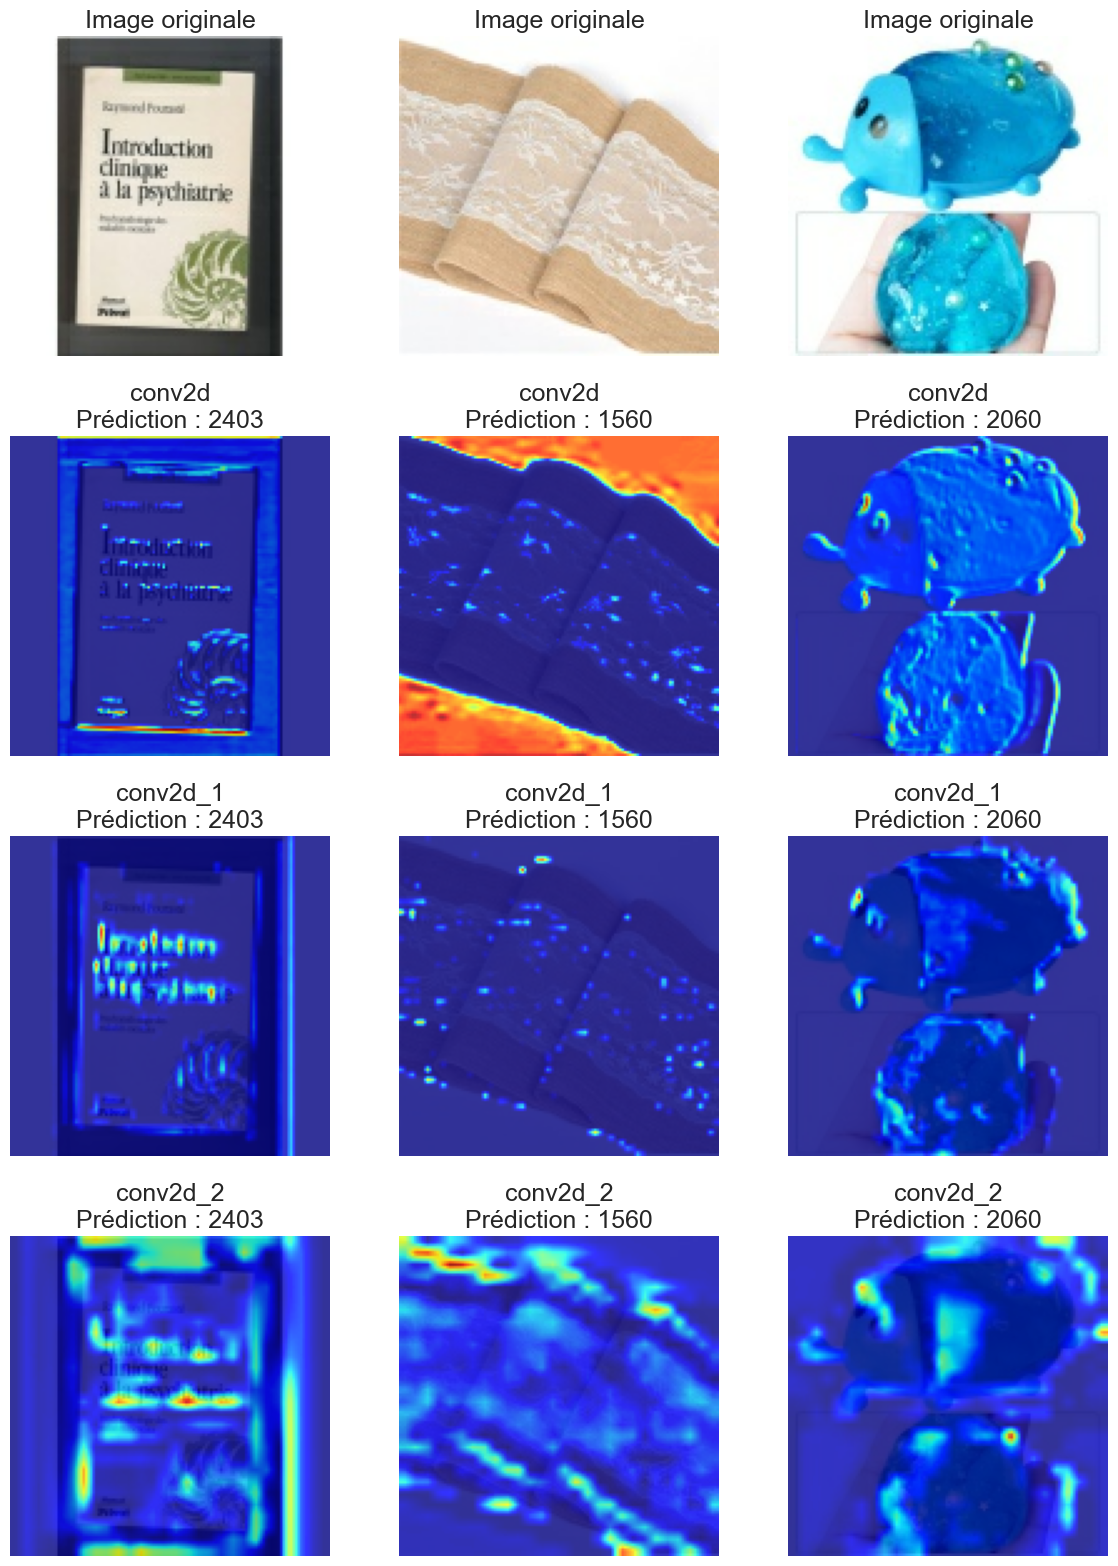

In [75]:
# ================================================================
# 11. INTERPRETABILITE : Grad-CAM
# ================================================================
# 11.2 Utiliser ce grad-CAM
# Rouge = zone la plus importante pour la prédiction
# Jaune = zone assez importante
# Vert = zone contributive mais faible
# Bleu = le modèle ne regarde pas cette zone
# ================================================================
sample_paths = test_df["imagepath"].sample(3).apply(lambda p: os.path.join(image_folder, p)).tolist()
show_grad_cam_from_paths(sample_paths, model)

In [51]:
# # ================================================================
# # Dans le cas où on ne fait pas SHAP tout de suite dans le notebook, juste après l'entrainement du modèle,
# # on peut Recharger le modèle pour l'utiliser (pas besoin de refaire l'entrainement)
# # ================================================================
# model = tf.keras.models.load_model("model_57.keras")


Images pour SHAP : (1, 128, 128, 3)
Explainer SHAP créé !


PartitionExplainer explainer: 2it [00:10, 10.50s/it]               


SHAP values calculées !


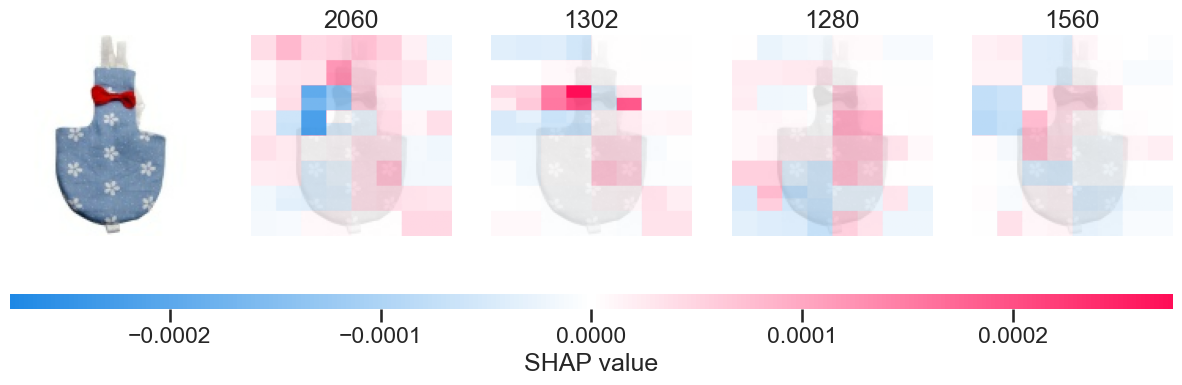

In [52]:
# ================================================================
# 12. INTERPRETABILITE : SHAP
# en rouge : les zones de l’image qui augmentent la probabilité d’une classe
# en bleu : les zones qui diminuent la probabilité
# ================================================================
# 12.1. EXTRAIRE QUELQUES IMAGES DU TEST SET
# ================================================================
# SHAP attend un batch d'images "numpy" avec shape (N, 128, 128, 3)
# On va donc prendre les 5 images du test_set (par ex.)

N_EXPLAIN = 1  # Ajustable

test_images = []
test_labels = []

for batch_imgs, batch_labels in test_ds:
    for i in range(len(batch_imgs)):
        test_images.append(batch_imgs[i].numpy())   # img → numpy
        test_labels.append(np.argmax(batch_labels[i].numpy()))
        if len(test_images) >= N_EXPLAIN:
            break
    if len(test_images) >= N_EXPLAIN:
        break

test_images = np.array(test_images)  # shape (N,128,128,3)
print("Images pour SHAP :", test_images.shape)


# 12.2. CRÉATION DU MASKER SHAP (pour images RGB 128×128)
# ================================================================
# On utilise un masker basé sur de l'inpainting (OpenCV)
masker = shap.maskers.Image("inpaint_telea", test_images[0].shape)


# 12.3. LISTE DES NOMS DE CLASSE (en texte)
# ================================================================
class_names = [str(idx_to_label[i]) for i in range(NUM_CLASSES)]


# 12.4. CRÉATION DE L'EXPLAINER SHAP POUR UN MODÈLE TENSORFLOW
# ================================================================
# SHAP va appeler model(img_batch) → softmax
# Pas besoin de wrapper supplémentaire
explainer = shap.Explainer(
    model,
    masker,
    output_names=class_names
)

print("Explainer SHAP créé !")


# 12.5. CALCUL DES VALEURS SHAP
# ================================================================
# outputs=... permet d'afficher les classes les plus importantes
# max_evals=500 = bon compromis vitesse/qualité

shap_values = explainer(
    test_images,
    max_evals=500,
    # On veut afficher les 4 classes les plus influentes
    outputs=shap.Explanation.argsort.flip[:4]
)

print("SHAP values calculées !")


# 12.6. AFFICHAGE
# ================================================================
shap.image_plot(shap_values)
